In [1]:
import os
import cv2
import sklearn
import pandas as pd
import numpy as np,random
import seaborn as sn
import tensorflow as tf
from sklearn.svm import SVC
from keras.optimizers import Adam
from sklearn.utils import shuffle
from sklearn.svm import LinearSVC
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import BatchNormalization,MaxPooling2D,Conv2D,Flatten,Dense,Dropout


In [2]:
path_of_dir=os.listdir('../brain tumor/')
classes_in_dir={'Brain Tumor':1,'Healthy':0}

classes_in_dir

{'Brain Tumor': 1, 'Healthy': 0}

In [3]:
def safe_mri_augment1(img):
    h, w = img.shape[:2]

    # 1. Fixed rotation (+3°)
    angle = 3
    M_rot = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2. Fixed zoom (1.02x)
    zf = 1.02
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    start_y = (zh - h) // 2
    start_x = (zw - w) // 2
    img = img[start_y:start_y + h, start_x:start_x + w]

    # 3. Fixed gamma correction
    gamma = 1.02
    img = np.power(img / 255.0, gamma) * 255
    img = img.astype(np.uint8)

    # 4. Deterministic constant noise (+1 pixel everywhere)
    fixed_noise = np.full(img.shape, 1, dtype=np.int16)
    img = np.clip(img.astype(np.int16) + fixed_noise, 0, 255).astype(np.uint8)

    return img



def safe_mri_augment2(img):
    # Mild brightness change (+0.05)
    img = np.clip(img + 0.05, 0, 1.0)
    
    # Mild contrast scaling (×1.05)
    img = np.clip(img * 1.05, 0, 1.0)
    
    # Optional: Gaussian blur to reduce noise
    img = cv2.GaussianBlur(img, (3, 3), 0)
    
    return img


def safe_mri_augment3(img):
    """
    Mild augmentation for MRI images suitable for SVM/ML models.
    Includes small rotation, slight zoom, brightness/gamma adjustment, blur, and horizontal flip.
    """
    h, w = img.shape[:2]

    # 1. Small fixed rotation (3°)
    M_rot = cv2.getRotationMatrix2D((w // 2, h // 2), 3, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2. Very small zoom (1.02x)
    zf = 1.02
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    start_y = max((zh - h) // 2, 0)
    start_x = max((zw - w) // 2, 0)
    img = img[start_y:start_y + h, start_x:start_x + w]

    # Convert to float for adjustments
    img = img.astype(np.float32)

    # 3. Mild brightness adjustment
    img += 5.0
    img = np.clip(img, 0, 255)

    # 4. Slight gamma correction
    gamma = 1.02
    img = 255.0 * np.power(img / 255.0, gamma)

    # 5. Gentle Gaussian blur
    img = cv2.GaussianBlur(img.astype(np.uint8), (3, 3), 0)

    # 6. Horizontal flip
    img = cv2.flip(img, 1)

    return img


def safe_mri_augment4(img):
    h, w = img.shape[:2]

    # 1. Small rotation (±3°)
    angle = 3
    M_rot = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2. Slight zoom (1.02x)
    zf = 1.02
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    start_y = (zh - h) // 2
    start_x = (zw - w) // 2
    img = img[start_y:start_y + h, start_x:start_x + w]

    # 3. Mild contrast adjustment
    gamma = 1.02
    img = np.power(img / 255.0, gamma) * 255
    img = img.astype(np.uint8)

    return img




 
def safe_mri_augment5(img):
    # Convert to float in [0,1]
    img = img.astype("float32") / 255.0  
    
    # Mild brightness
    img = np.clip(img + 0.05, 0, 1.0)
    
    # Mild contrast
    img = np.clip(img * 1.05, 0, 1.0)
    
    # Gaussian blur (cv2 expects 0–1 float too)
    img = cv2.GaussianBlur(img, (3, 3), 0)
    
    return img

In [4]:
# --------------------
# Load dataset
# --------------------
path_of_dir = os.listdir('../brain tumor/')
classes_in_dir = {'Brain Tumor': 1, 'Healthy': 0}

X, Y = [], []
for cls in classes_in_dir:
    path = '../brain tumor/' + cls
    for file in os.listdir(path):
        img = cv2.imread(os.path.join(path, file), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (200, 200))
        X.append(img)
        Y.append(classes_in_dir[cls])

x = np.array(X, dtype="float32")
y = np.array(Y)

# --------------------
# Train/test split
# --------------------
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, shuffle=True, random_state=42
)

# --------------------
# Augmentations (make sure these functions exist)
# --------------------
x_train_aug1 = np.array([safe_mri_augment1(img) for img in x_train], dtype="float32")
x_train_aug2 = np.array([safe_mri_augment2(img) for img in x_train], dtype="float32")
x_train_aug3 = np.array([safe_mri_augment3(img) for img in x_train], dtype="float32")
x_train_aug4 = np.array([safe_mri_augment4(img) for img in x_train], dtype="float32")
x_train_aug5 = np.array([safe_mri_augment5(img) for img in x_train], dtype="float32")

# --------------------
# Combine original + augmentation with labels
# --------------------
def combine_with_labels(x_orig, y_orig, x_aug):
    x_comb = np.concatenate([x_orig, x_aug], axis=0)
    y_comb = np.concatenate([y_orig, y_orig], axis=0)  # duplicate labels
    return x_comb, y_comb

# Create dataset variants for each model
x_train_cnn, y_train_cnn = combine_with_labels(x_train, y_train, x_train_aug1)  # CNN
x_train_rf,  y_train_rf  = combine_with_labels(x_train, y_train, x_train_aug2)  # RF
x_train_svm, y_train_svm = combine_with_labels(x_train, y_train, x_train_aug3)  # SVM
x_train_knn, y_train_knn = combine_with_labels(x_train, y_train, x_train_aug4)  # KNN
x_train_lr,  y_train_lr  = combine_with_labels(x_train, y_train, x_train_aug5)  # LR

# --------------------
# Normalize / reshape
# --------------------
# CNN: keep 4D
x_train_cnn = x_train_cnn.reshape(-1, 200, 200, 1) / 255.0
x_test_cnn  = x_test.reshape(-1, 200, 200, 1) / 255.0

# ML models: flatten 2D
x_train_rf  = x_train_rf.reshape(len(x_train_rf), -1) / 255.0
x_train_svm = x_train_svm.reshape(len(x_train_svm), -1) / 255.0
x_train_knn = x_train_knn.reshape(len(x_train_knn), -1) / 255.0
x_train_lr  = x_train_lr.reshape(len(x_train_lr), -1) / 255.0
x_test_ml   = x_test.reshape(len(x_test), -1) / 255.0

# --------------------
# StandardScaler (fit once on base training data!)
# --------------------
scaler = StandardScaler()
scaler.fit(x_train.reshape(len(x_train), -1) / 255.0)  # fit on original training set

x_train_rf  = scaler.transform(x_train_rf)
x_train_svm = scaler.transform(x_train_svm)
x_train_knn = scaler.transform(x_train_knn)
x_train_lr  = scaler.transform(x_train_lr)
x_test_ml   = scaler.transform(x_test_ml)

# --------------------
# Labels
# --------------------
y_train_cnn = np.array(y_train_cnn)
y_train_rf  = np.array(y_train_rf)
y_train_svm = np.array(y_train_svm)
y_train_knn = np.array(y_train_knn)
y_train_lr  = np.array(y_train_lr)
y_test      = np.array(y_test)

# --------------------
# Check shapes
# --------------------
print("CNN Train:", x_train_cnn.shape, y_train_cnn.shape)
print("RF Train :", x_train_rf.shape,  y_train_rf.shape)
print("SVM Train:", x_train_svm.shape, y_train_svm.shape)
print("KNN Train:", x_train_knn.shape, y_train_knn.shape)
print("LR Train :", x_train_lr.shape,  y_train_lr.shape)
print("CNN Test :", x_test_cnn.shape, y_test.shape)
print("ML Test  :", x_test_ml.shape, y_test.shape)


CNN Train: (6400, 200, 200, 1) (6400,)
RF Train : (6400, 40000) (6400,)
SVM Train: (6400, 40000) (6400,)
KNN Train: (6400, 40000) (6400,)
LR Train : (6400, 40000) (6400,)
CNN Test : (800, 200, 200, 1) (800,)
ML Test  : (800, 40000) (800,)


In [5]:
#plt.imshow(x_test3D[5])
#plt.xlabel(y_test3D[5])


#CNN MODEL

In [6]:
cnn=Sequential([keras.layers.Input(shape=(200,200,1)),
Conv2D(filters=32, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Conv2D(filters=64, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Flatten(),
Dense(1, activation='sigmoid')

])

cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 198, 198, 32)      320       
                                                                 
 batch_normalization (BatchN  (None, 198, 198, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 99, 99, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 97, 97, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 97, 97, 64)       256       
 hNormalization)                                                 
                                                        

In [7]:
cnn.compile(optimizer=Adam(learning_rate=1e-4),loss='binary_crossentropy', metrics=['accuracy'])

In [8]:
cnn.fit(x_train_cnn,y_train_cnn,validation_data=(x_test_cnn,y_test), epochs=3, batch_size=16)

Epoch 1/3
400/400 [==============================] - 117s 291ms/step - loss: 0.4133 - accuracy: 0.8633 - val_loss: 0.3146 - val_accuracy: 0.8575
Epoch 2/3
400/400 [==============================] - 116s 290ms/step - loss: 0.0819 - accuracy: 0.9708 - val_loss: 0.1268 - val_accuracy: 0.9463
Epoch 3/3
400/400 [==============================] - 115s 288ms/step - loss: 0.0297 - accuracy: 0.9906 - val_loss: 0.1512 - val_accuracy: 0.9600


In [9]:
test_loss,test_acc=cnn.evaluate(x_test_cnn,y_test,verbose=2)

25/25 - 4s - loss: 0.1512 - accuracy: 0.9600 - 4s/epoch - 159ms/step


In [10]:
pred1=(cnn.predict(x_test_cnn)>0.5).astype('int').flatten()

25/25 [==============================] - 4s 149ms/step


In [11]:
print(pred1[0:20])

[1 0 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 1]


In [12]:
accuracy_score(y_test,pred1)

0.96

In [13]:
conf_mat= confusion_matrix(y_test,pred1)
print(classification_report(y_test,pred1))


              precision    recall  f1-score   support

           0       0.98      0.93      0.96       378
           1       0.94      0.98      0.96       422

    accuracy                           0.96       800
   macro avg       0.96      0.96      0.96       800
weighted avg       0.96      0.96      0.96       800



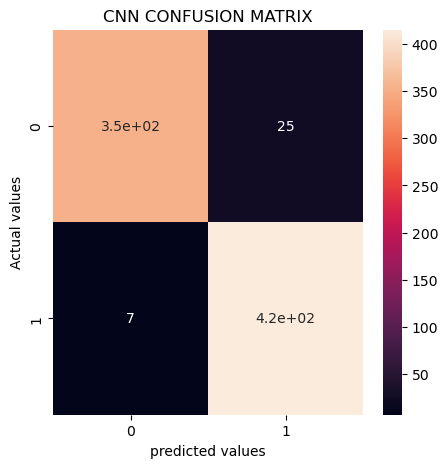

In [14]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("CNN CONFUSION MATRIX")
plt.show()

#Random forest

In [15]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_rf, y_train_rf)


RandomForestClassifier(random_state=42)

In [16]:
pred2=rf.predict(x_test_ml)

In [17]:
print("RF Train:", rf.score(x_train_rf, y_train_rf))
print("RF Val  :", accuracy_score(y_test, pred2))


RF Train: 0.98515625
RF Val  : 0.96125


In [18]:

conf_mat2=confusion_matrix(y_test,pred2)


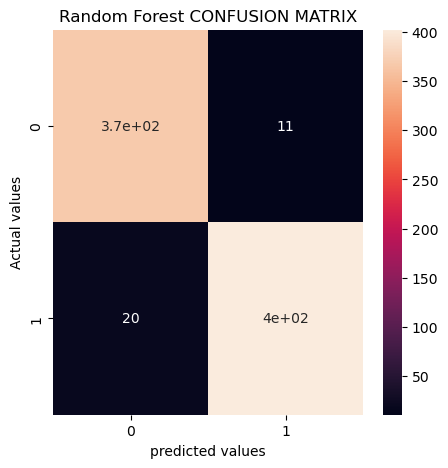

In [19]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat2,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Random Forest CONFUSION MATRIX")
plt.show()

#SVM

In [20]:

# ----------------------
# SVM Pipeline
# ----------------------
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),          # standardize features
    ('pca', PCA(n_components=500)),        # reduce dimensionality
    ('svm', SVC(kernel='rbf', C=5.0, gamma='scale'))  # RBF kernel
])

# Fit the model
svm_pipeline.fit(x_train_svm, y_train_svm)

# Predictions
pred_train = svm_pipeline.predict(x_train_svm)
pred3 = svm_pipeline.predict(x_test_ml)

# Accuracy
train_acc = svm_pipeline.score(x_train_svm, y_train_svm)
val_acc   = svm_pipeline.score(x_test_ml, y_test)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)


Train Accuracy: 0.996875
Validation Accuracy: 0.975


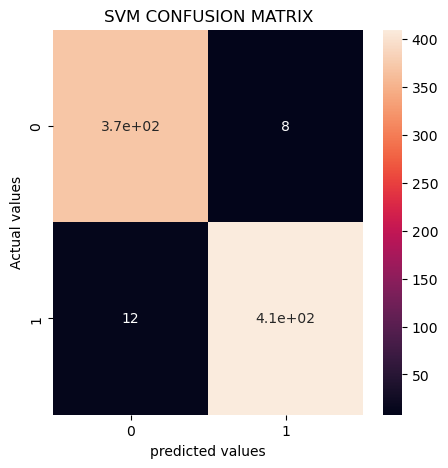

In [21]:
conf_mat3=confusion_matrix(y_test,pred3)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat3,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("SVM CONFUSION MATRIX")
plt.show()

#KNN

In [22]:
knn =KNeighborsClassifier(n_neighbors=3, weights='distance',metric= 'manhattan')
knn.fit(x_train_knn, y_train_knn) 

KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')

In [23]:
pred4=knn.predict(x_test_ml)

In [24]:
print("Accuracy:", accuracy_score(y_test, pred4))

Accuracy: 0.955


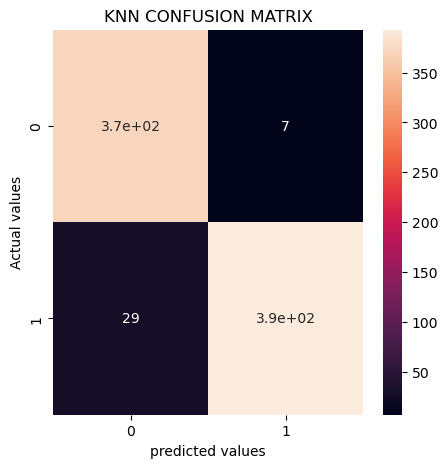

In [25]:
conf_mat4=confusion_matrix(y_test,pred4)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat4,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("KNN CONFUSION MATRIX")
plt.show()

#Logistic Regression

In [26]:
LR = LogisticRegression(
    C=0.05,
    class_weight="balanced",
    penalty='l2',
    solver='liblinear',
    max_iter=100
)
LR.fit(x_train_lr, y_train_lr)

LogisticRegression(C=0.05, class_weight='balanced', solver='liblinear')

In [27]:
print("Train:", LR.score(x_train_lr, y_train_lr))
print("Validation:", LR.score(x_test_ml, y_test))

Train: 0.99578125
Validation: 0.9425


In [28]:
pred5 = LR.predict(x_test_ml)

print("Accuracy:", accuracy_score(y_test, pred5))
print("\nClassification Report:\n", classification_report(y_test, pred5))

Accuracy: 0.9425

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94       378
           1       0.95      0.95      0.95       422

    accuracy                           0.94       800
   macro avg       0.94      0.94      0.94       800
weighted avg       0.94      0.94      0.94       800



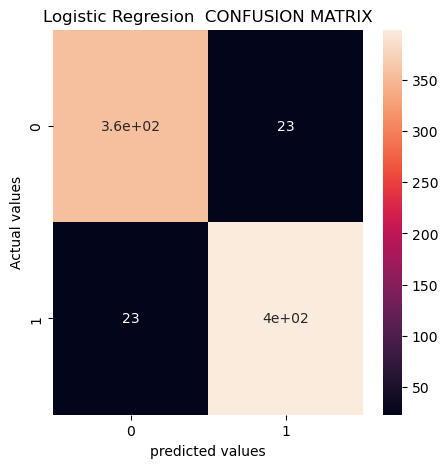

In [29]:
conf_mat5= confusion_matrix(y_test,pred5)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat5,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Logistic Regresion  CONFUSION MATRIX")
plt.show()

# ALL PREDICTED VALUES

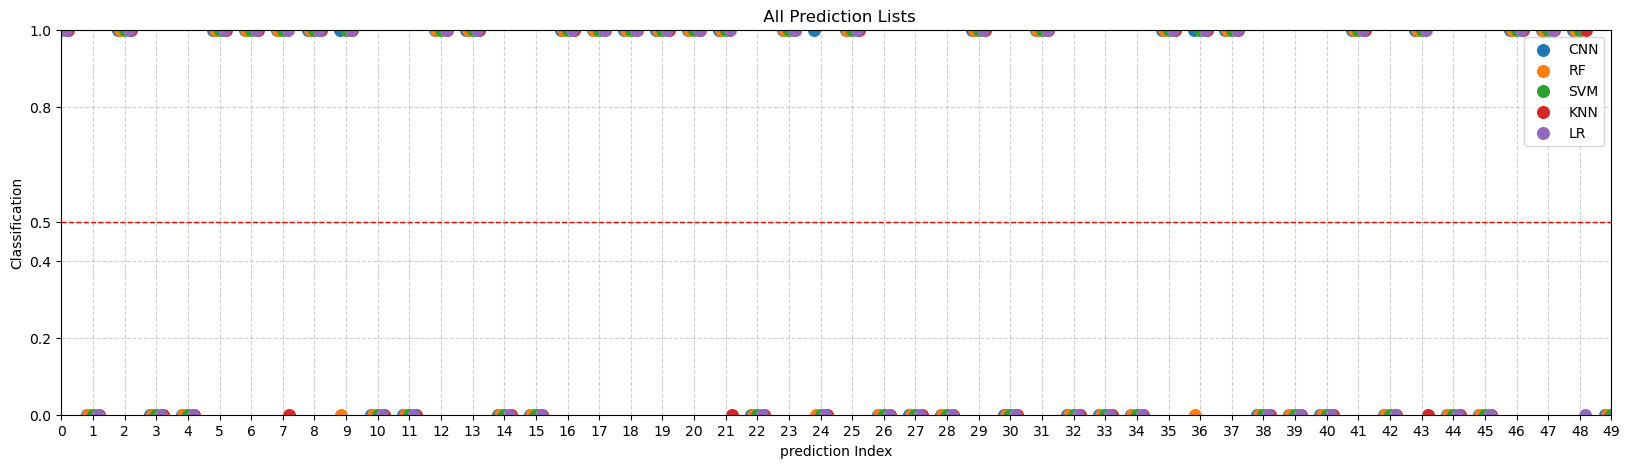

In [30]:
sze=np.arange(len(pred1))
plt.figure(figsize=(20,5))
plt.scatter(sze - 0.2, pred1, label='CNN', alpha=1, s=70)
plt.scatter(sze - 0.15, pred2, label='RF', alpha=1, s=70)
plt.scatter(sze, pred3, label='SVM', alpha=1, s=70)
plt.scatter(sze + 0.2, pred4, label='KNN', alpha=1, s=70)
plt.scatter(sze + 0.15 , pred5, label='LR', alpha=1, s=70)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)

plt.ylim(0,1)
plt.xlim(0,10)
plt.xticks(range(0,50))
plt.yticks([0, 0.2,0.4,0.5,0.8,1])
plt.xlabel('prediction Index')
plt.ylabel('Classification')
plt.title(' All Prediction Lists')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [31]:
pp1=(cnn.predict(x_test_cnn)>0.5).astype('int').flatten()
pp2=rf.predict(x_test_ml)
pp3=svm_pipeline.predict(x_test_ml)
pp4=knn.predict(x_test_ml)
pp5=LR.predict(x_test_ml)

25/25 [==============================] - 4s 138ms/step


In [32]:
print(pp1[0:2])

[1 0]


In [33]:
total_prediction=[]
for i in range(len(pp3)):
    totaladd=pp1[i]+pp2[i]+pp3[i]+pp4[i]+pp5[i]
    total_prediction.append(totaladd)


In [34]:
Ensemble_prediction = [1 if val >= 3 else 0 for val in total_prediction]
print(Ensemble_prediction[:6])

[1, 0, 1, 0, 0, 1]


In [35]:
print(y_test[0:6])

[1 0 1 0 0 1]


In [36]:
print(pred1[0:6])

[1 0 1 0 0 1]


In [37]:
print(pred2[0:6])

[1 0 1 0 0 1]


In [38]:
print(pred3[0:6])

[1 0 1 0 0 1]


In [39]:
print(pred4[0:6])

[1 0 1 0 0 1]


In [40]:
print(pred5[0:6])

[1 0 1 0 0 1]


In [41]:
g=np.where(y_test != Ensemble_prediction)[0]
print(g)

[ 53  72  92 110 179 184 313 362 369 382 460 509 530 544 582 707 719]


In [42]:
print("Accuracy:", accuracy_score(y_test, Ensemble_prediction))
print("\nClassification Report:\n", classification_report(y_test, Ensemble_prediction))

Accuracy: 0.97875

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98       378
           1       0.97      0.99      0.98       422

    accuracy                           0.98       800
   macro avg       0.98      0.98      0.98       800
weighted avg       0.98      0.98      0.98       800



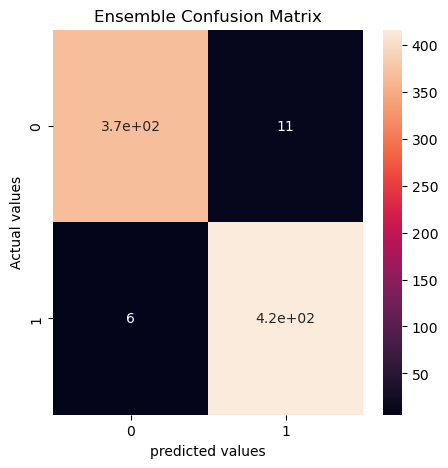

In [43]:
ensemble_confusion_matrix= confusion_matrix(y_test,Ensemble_prediction)
plt.figure(figsize=(5,5))
sn.heatmap(ensemble_confusion_matrix,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Ensemble Confusion Matrix")
plt.show()

In [44]:
x_pred, y_pred = [], []
img_path = r"D:\My Final Work\external_pic" 
for j in os.listdir(img_path):
        pic = cv2.imread(img_path + '/' + j, 0)  
        pic = cv2.resize(pic, (200, 200))                       
        pic = np.array(pic)
        x_pred.append(pic)
        y_pred.append(j)


(-0.5, 199.5, 199.5, -0.5)

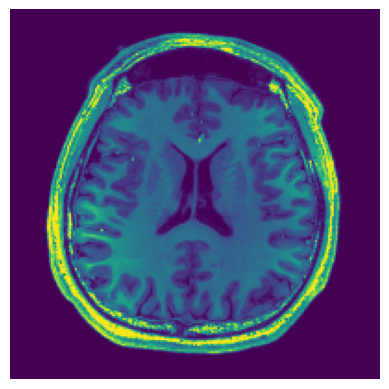

In [45]:
plt.imshow(x_pred[1])
plt.axis('off')

In [46]:
img_path = r"D:\My Final Work\external_pic"
images_cnn = []   
images_flat = []  
filenames = []

for file in os.listdir(img_path):
    path = os.path.join(img_path, file)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (200, 200))
    images_cnn.append(img)
    images_flat.append(img.reshape(-1))
    filenames.append(file)
images_cnn = np.array(images_cnn).reshape(-1, 200, 200, 1) / 255.0
images_flat =np.array(images_flat)/255
pred_cnn = (cnn.predict(images_cnn) > 0.5).astype(int).flatten()
pred_rf  = rf.predict(images_flat)
pred_svm = svm_pipeline.predict(images_flat)
pred_lr  = LR.predict(images_flat)
pred_knn = knn.predict(images_flat)
results = []
for i, name in enumerate(filenames):
    votes = pred_cnn[i] + pred_rf[i] + pred_svm[i] + pred_lr[i] + pred_knn[i]
    if votes >= 3:
        label = "Tumor"
    else:
        label = "No Tumor"

    results.append((name, label))
print("\n Total Predictions:")
for file, label in results:
   print(file + " -------> " + label)



1/1 [==============================] - 0s 161ms/step

 Total Predictions:
h1.jpeg -------> No Tumor
h2.jpg -------> No Tumor
h3.jpeg -------> No Tumor
h4.jpeg -------> Tumor
h5.jpeg -------> No Tumor
h6.jpg -------> No Tumor
t1.jpeg -------> No Tumor
t4.jpeg -------> No Tumor
t5.png -------> No Tumor
t6.jpeg -------> Tumor


In [47]:
img_path2 = r"D:\My Final Work\external_pic/t1.jpeg" 
pic1 = cv2.imread(img_path2,0)  
pic1= cv2.resize(pic1, (200, 200))


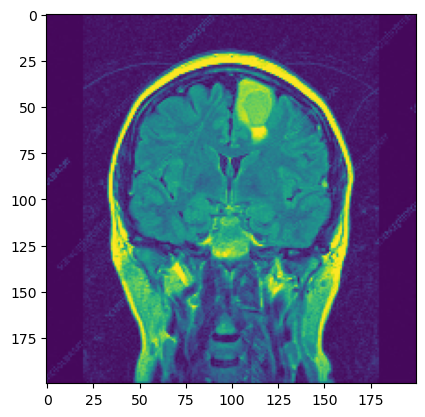

In [48]:
plt.imshow(pic1)

In [49]:
cnnpred1 = pic1.reshape(1, 200, 200, 1)
cnnpred = cnnpred1 / 255.0

In [50]:
cnnpred.shape

(1, 200, 200, 1)

In [51]:
p11 = (cnn.predict(cnnpred) > 0.5).astype('int').flatten()

1/1 [==============================] - 0s 33ms/step


In [52]:
print(p11)

[0]


In [53]:
p_2D=cnnpred.reshape(1, -1)
p_2D.shape

(1, 40000)

In [54]:
x_scaled = p_2D/255
p22=rf.predict(x_scaled)
p33=svm_pipeline.predict(x_scaled)
p44=LR.predict(x_scaled)
p55 = knn.predict(x_scaled)
print('CNN =',p11)
print('RF =',p22)
print('SVM =',p33)
print('LR =',p44)
print('KNN =',p55)

if(p11+p22+p33+p44+p55 >= 3):
    print(" \n Tumor")
elif (p11+p22+p33+p44+p55 < 3):
    print( "\n No Tumor")

CNN = [0]
RF = [0]
SVM = [0]
LR = [0]
KNN = [0]

 No Tumor
